In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
SEED = 42

FIG_ROOT    = '../figures/04_linear_regression'
###FIG_ROOT    = '../figures_test/04_linear_regression'

FIG_METRICS = f'{FIG_ROOT}/metrics'      # so sánh R², RMSE, heatmap
FIG_RESID   = f'{FIG_ROOT}/residuals'    # phân tích phần dư
for _d in [FIG_METRICS, FIG_RESID]:
    os.makedirs(_d, exist_ok=True)
print('Figure folders ready:', FIG_ROOT)

Figure folders ready: ../figures/04_linear_regression


# 1. Load dữ liệu

In [2]:
DATA_PATH = os.path.join('..', 'processed_data', 'encoded_ai_company_adoption.csv')
META_PATH = os.path.join('..', 'processed_data', 'meta_data.json')
TARGET_COL = 'ai_failure_rate'


def load_base_data():
    df = pd.read_csv(DATA_PATH)
    with open(META_PATH, 'r', encoding='utf-8') as f:
        meta_data = json.load(f)

    numeric_ordinal_cols = meta_data['numeric_ordinal_cols'].copy()
    onehot_cols = meta_data['onehot_cols']
    cyclic_cols = meta_data['cyclic_cols']
    binary_cols = meta_data['binary_cols']

    if TARGET_COL in numeric_ordinal_cols:
        numeric_ordinal_cols.remove(TARGET_COL)

    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL].values
    return df, X, y, numeric_ordinal_cols, onehot_cols, cyclic_cols, binary_cols


df_encoded, X, y, NUMERIC_ORDINAL_COLS, ONEHOT_COLS, CYCLIC_COLS, BINARY_COLS = load_base_data()


def preprocess_data(X_train, X_val):
    valid_num_cols = [col for col in NUMERIC_ORDINAL_COLS if col in X_train.columns]
    valid_cat_cols = [col for col in ONEHOT_COLS if col in X_train.columns]
    valid_cyc_cols = [col for col in CYCLIC_COLS if col in X_train.columns]

    scaler = StandardScaler()

    X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float)) if valid_num_cols else np.empty((len(X_train), 0))
    X_val_num = scaler.transform(X_val[valid_num_cols].astype(float)) if valid_num_cols else np.empty((len(X_val), 0))

    X_train_cat = X_train[valid_cat_cols].astype(float).values if valid_cat_cols else np.empty((len(X_train), 0))
    X_val_cat = X_val[valid_cat_cols].astype(float).values if valid_cat_cols else np.empty((len(X_val), 0))

    if valid_cat_cols:
        train_col_means = X_train_cat.mean(axis=0)
        train_col_means = np.where(train_col_means == 0, 1e-8, train_col_means)
        X_train_cat_scaled = X_train_cat / np.sqrt(train_col_means)
        X_val_cat_scaled = X_val_cat / np.sqrt(train_col_means)
    else:
        X_train_cat_scaled = X_train_cat
        X_val_cat_scaled = X_val_cat

    X_train_cyc = X_train[valid_cyc_cols].astype(float).values if valid_cyc_cols else np.empty((len(X_train), 0))
    X_val_cyc = X_val[valid_cyc_cols].astype(float).values if valid_cyc_cols else np.empty((len(X_val), 0))

    X_train_combined = np.hstack([X_train_num, X_train_cat_scaled, X_train_cyc])
    X_val_combined = np.hstack([X_val_num, X_val_cat_scaled, X_val_cyc])

    final_columns = valid_num_cols + valid_cat_cols + valid_cyc_cols
    X_train_combined = pd.DataFrame(X_train_combined, columns=final_columns, index=X_train.index)
    X_val_combined = pd.DataFrame(X_val_combined, columns=final_columns, index=X_val.index)
    return X_train_combined, X_val_combined


def get_optimal_svd_components(X_train_scaled, target_variance=0.8, random_state=SEED):
    max_cols = max(1, X_train_scaled.shape[1] - 1)
    svd_test = TruncatedSVD(n_components=max_cols, random_state=random_state)
    svd_test.fit(X_train_scaled)
    cumulative_variance = np.cumsum(svd_test.explained_variance_ratio_)
    if not np.any(cumulative_variance >= target_variance):
        return max_cols
    return np.argmax(cumulative_variance >= target_variance) + 1


def prepare_features(X_train_raw, X_val_raw, method='Original', target_variance=0.8, random_state=SEED):
    X_train_ready, X_val_ready = preprocess_data(X_train_raw, X_val_raw)

    if method.upper() == 'ORIGINAL':
        return X_train_ready, X_val_ready

    if method.upper() == 'PCA':
        reducer = PCA(n_components=target_variance, random_state=random_state)
        return reducer.fit_transform(X_train_ready), reducer.transform(X_val_ready)

    if method.upper() == 'SVD':
        n_components = get_optimal_svd_components(
            X_train_ready,
            target_variance=target_variance,
            random_state=random_state
        )
        reducer = TruncatedSVD(n_components=n_components, random_state=random_state)
        return reducer.fit_transform(X_train_ready), reducer.transform(X_val_ready)

    raise ValueError(f'data_type không hợp lệ: {method}')


print(f'Loaded data: X={X.shape}, y={y.shape}')

Loaded data: X=(150000, 86), y=(150000,)


# 2. Hàm đánh giá - metrics đầy đủ

In [3]:
def get_metrics(y_true, y_pred, n_features):
    """Trả về dict các chỉ số hồi quy."""
    n = len(y_true)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Adjusted R²
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    # MAPE – tránh chia 0
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return dict(MSE=mse, RMSE=rmse, MAE=mae, R2=r2, Adj_R2=adj_r2, MAPE=mape)

In [4]:
def evaluate_lr(X_train, X_val, y_train, y_val):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_val_pred   = model.predict(X_val)
    n_feat = X_train.shape[1]
    train_m = get_metrics(y_train, y_train_pred, n_feat)
    val_m   = get_metrics(y_val,   y_val_pred,   n_feat)
    residuals = y_val - y_val_pred
    return model, train_m, val_m, y_val_pred, residuals

# 3. Chạy thực nghiệm

In [5]:
split_configs = [('80/20', 0.2), ('70/30', 0.3), ('60/40', 0.4)]
data_types = ['Original', 'PCA', 'SVD']

results = []
residuals_store = {}  # key: data_type  (chỉ lưu split 80/20)

for split_label, test_size in split_configs:
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=SEED
    )

    for dt in data_types:
        X_train_ready, X_val_ready = prepare_features(
            X_train_raw,
            X_val_raw,
            method=dt,
            target_variance=0.8,
            random_state=SEED
        )

        model, tr_m, val_m, y_pred, resid = evaluate_lr(X_train_ready, X_val_ready, y_train, y_val)

        results.append({
            'Data': dt,
            'Split': split_label,
            'Train_MSE': tr_m['MSE'],   'Train_RMSE': tr_m['RMSE'], 'Train_R2': tr_m['R2'],
            'Val_MSE':   val_m['MSE'],  'Val_RMSE':   val_m['RMSE'], 'Val_R2': val_m['R2'],
            'Train_MAE': tr_m['MAE'],
            'Val_MAE':   val_m['MAE'],
            'Val_Adj_R2': val_m['Adj_R2'], 'Val_MAPE': val_m['MAPE'],
            'Delta_R2':  round(tr_m['R2'] - val_m['R2'], 6),
        })

        if split_label == '80/20':
            residuals_store[dt] = {
                'residuals': resid,
                'y_pred': y_pred,
                'y_val': y_val,
                'X_val': X_val_raw.copy().reset_index(drop=True),
                'X_val_model': X_val_ready,
                'model': model
            }

results_df = pd.DataFrame(results)
print("=== Bảng kết quả đầy đủ ===")
display_cols = ['Data', 'Split',
                'Train_R2', 'Val_R2', 'Delta_R2',
                'Train_MSE', 'Val_MSE',
                'Train_RMSE', 'Val_RMSE',
                'Train_MAE', 'Val_MAE',
                'Val_MAPE', 'Val_Adj_R2']
results_df[display_cols]

=== Bảng kết quả đầy đủ ===


,Data,Split,Train_R2,Val_R2,Delta_R2,Train_MSE,Val_MSE,Train_RMSE,Val_RMSE,Train_MAE,Val_MAE,Val_MAPE,Val_Adj_R2
0,Original,80/20,0.610948,0.606654,0.004294,23.463535,23.572336,4.843917,4.855135,3.881136,3.884180,19.469157,0.605523
1,PCA,80/20,0.522918,0.519707,0.003212,28.772544,28.782867,5.364004,5.364967,4.310453,4.316240,21.947690,0.518969
2,SVD,80/20,0.522195,0.519047,0.003148,28.816165,28.822388,5.368069,5.368649,4.313031,4.319947,21.979837,0.518293
3,Original,70/30,0.610303,0.609510,0.000794,23.508696,23.435908,4.848577,4.841065,3.883484,3.878129,19.473161,0.608762
4,PCA,70/30,0.522912,0.522221,0.000691,28.780621,28.674650,5.364757,5.354872,4.310078,4.308547,21.853910,0.521732
5,SVD,70/30,0.522116,0.521625,0.000491,28.828624,28.710447,5.369229,5.358213,4.313048,4.311287,21.876463,0.521125
6,Original,60/40,0.610398,0.609434,0.000964,23.481245,23.503325,4.845745,4.848023,3.883503,3.880770,21.214805,0.608874
7,PCA,60/40,0.522662,0.522261,0.000401,28.769076,28.749222,5.363681,5.361830,4.309845,4.311319,23.423052,0.521894
8,SVD,60/40,0.521768,0.521708,0.000060,28.822990,28.782484,5.368705,5.364931,4.313308,4.313705,23.489676,0.521333


# 4. Biểu đồ so sánh – Đường (Line chart)

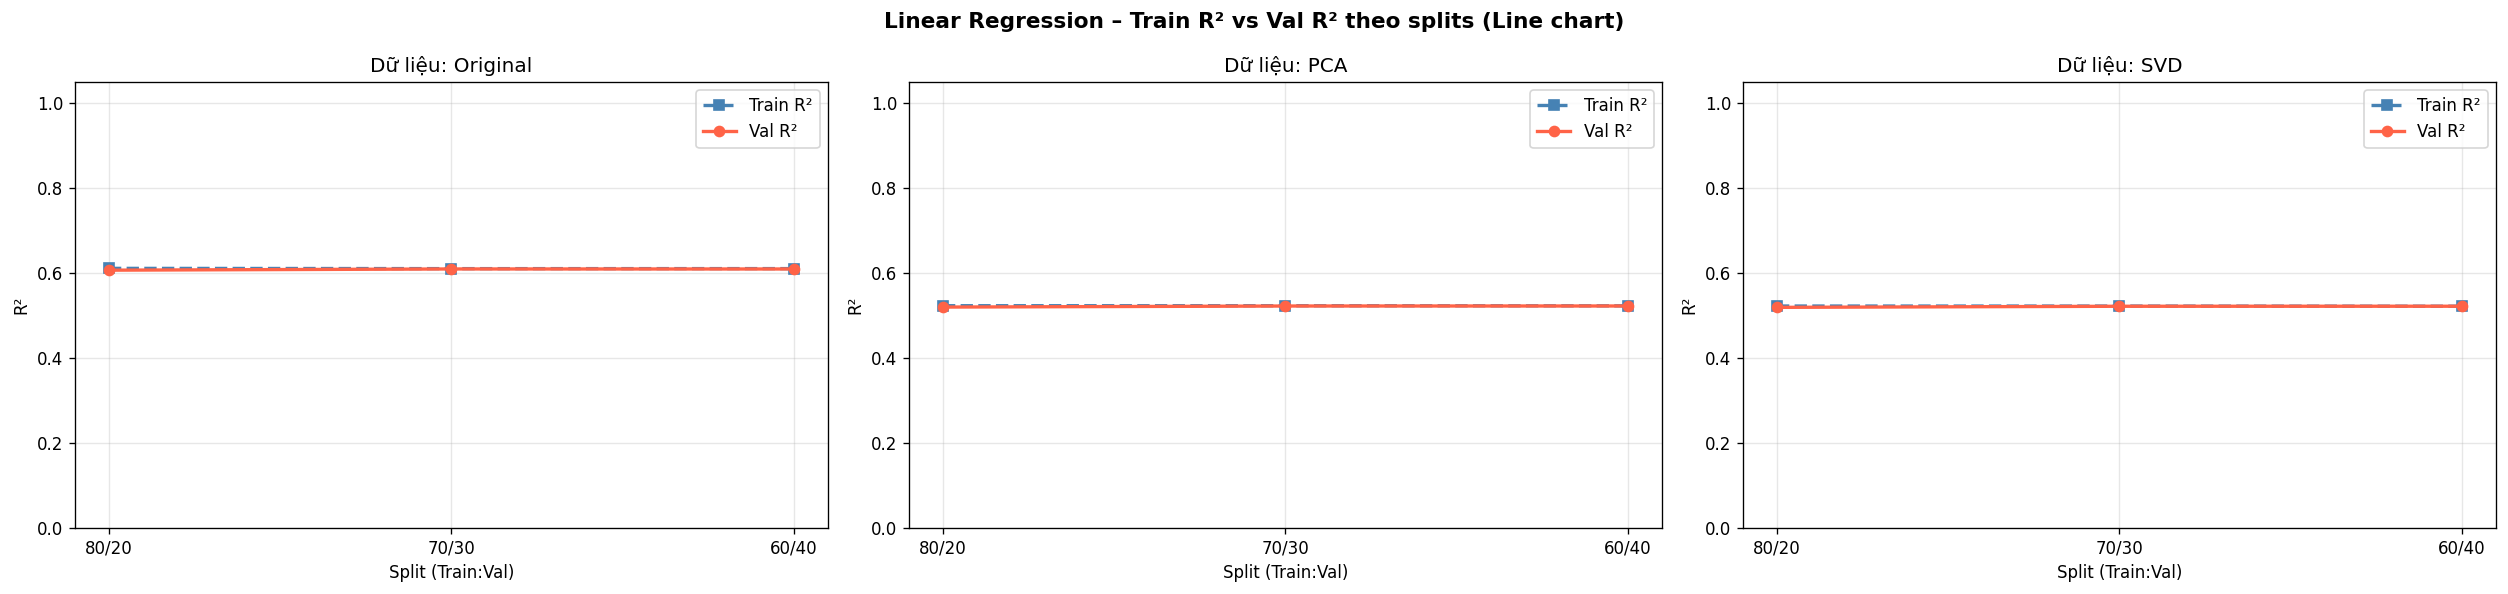

In [6]:
# 4.1 Line chart: Train R² vs Val R² theo splits (theo từng data type)
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]

fig, axes = plt.subplots(1, len(avail_dt), figsize=(7*len(avail_dt), 5))
if len(avail_dt) == 1: axes = [axes]
fig.suptitle('Linear Regression – Train R² vs Val R² theo splits (Line chart)',
             fontsize=13, fontweight='bold')

split_order = ['80/20', '70/30', '60/40']
for ax, data_type in zip(axes, avail_dt):
    sub = results_df[results_df['Data'] == data_type].set_index('Split').reindex(split_order)
    ax.plot(split_order, sub['Train_R2'], marker='s', linestyle='--',
            color='steelblue', linewidth=2, label='Train R²')
    ax.plot(split_order, sub['Val_R2'], marker='o',
            color='tomato', linewidth=2, label='Val R²')
    ax.set_xlabel('Split (Train:Val)')
    ax.set_ylabel('R²')
    ax.set_title(f'Dữ liệu: {data_type}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/r2_line_comparison.png', bbox_inches='tight')
plt.show()


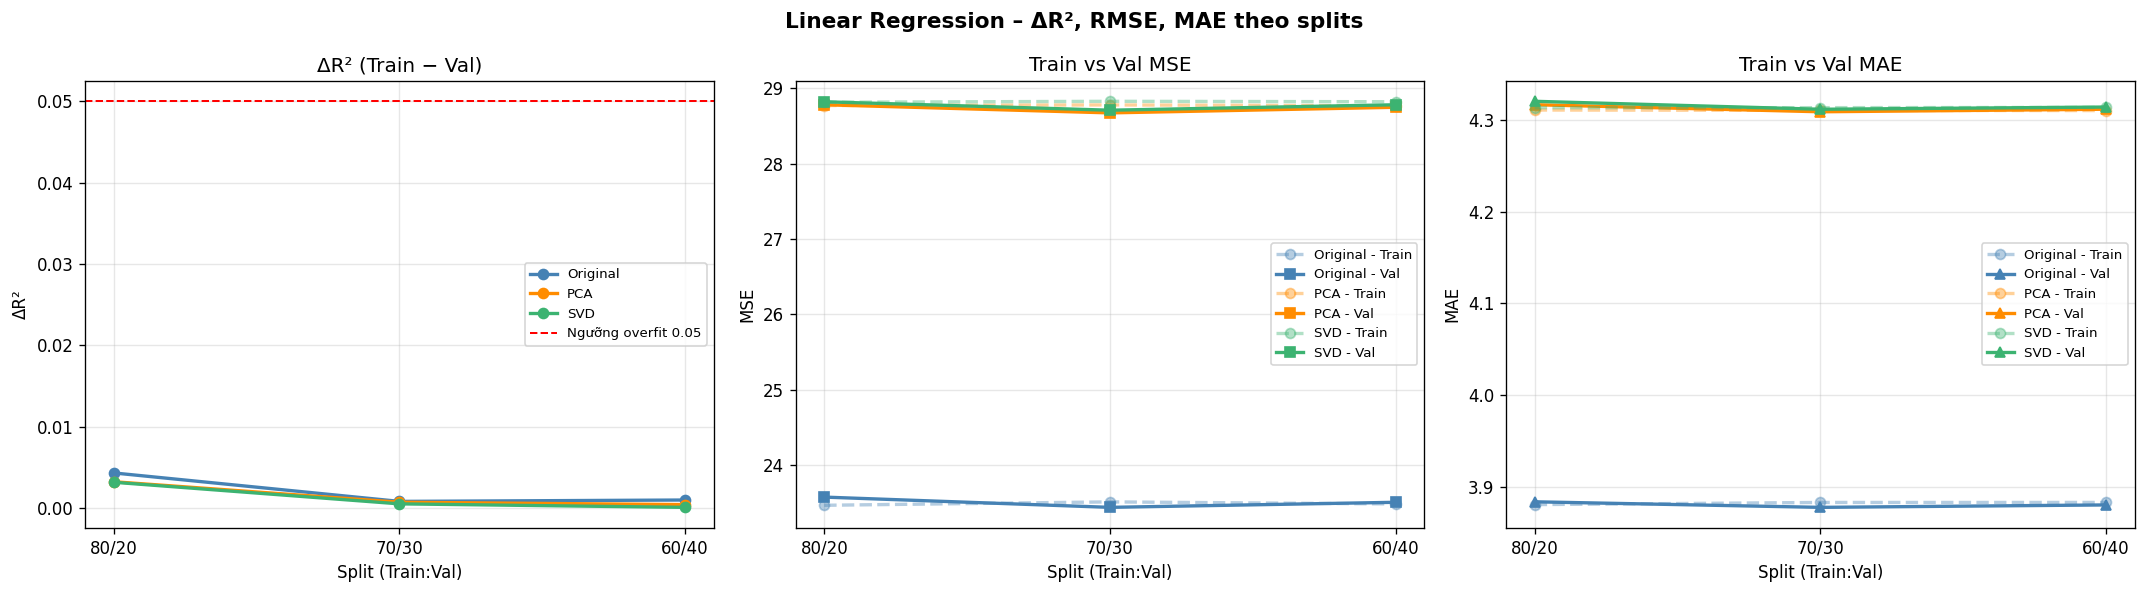

In [7]:
# 4.2 Line chart: Delta R² (gap), MSE, MAE theo splits
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
split_order = ['80/20', '70/30', '60/40']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Linear Regression – ΔR², RMSE, MAE theo splits', fontsize=13, fontweight='bold')

colors_dt = {'Original': 'steelblue', 'PCA': 'darkorange', 'SVD': 'mediumseagreen'}

# Delta R²
ax = axes[0]
for dt in avail_dt:
    sub = results_df[results_df['Data'] == dt].set_index('Split').reindex(split_order)
    ax.plot(split_order, sub['Delta_R2'], marker='o', linewidth=2,
            color=colors_dt.get(dt, 'gray'), label=dt)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.2, label='Ngưỡng overfit 0.05')
ax.set_title('ΔR² (Train − Val)')
ax.set_ylabel('ΔR²')
ax.set_xlabel('Split (Train:Val)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Val + Train MSE
ax = axes[1]

for dt in avail_dt:
    sub = results_df[results_df['Data'] == dt].set_index('Split').reindex(split_order)
    
    base_color = colors_dt.get(dt, 'gray')
    
    # Train (nhạt)
    ax.plot(split_order, sub['Train_MSE'],
            marker='o', linestyle='--', linewidth=2,
            color=base_color, alpha=0.4,
            label=f'{dt} - Train')
    
    # Val (đậm)
    ax.plot(split_order, sub['Val_MSE'],
            marker='s', linestyle='-', linewidth=2,
            color=base_color, alpha=1.0,
            label=f'{dt} - Val')

ax.set_title('Train vs Val MSE')
ax.set_ylabel('MSE')
ax.set_xlabel('Split (Train:Val)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Train + Val MAE
ax = axes[2]

for dt in avail_dt:
    sub = results_df[results_df['Data'] == dt].set_index('Split').reindex(split_order)
    
    base_color = colors_dt.get(dt, 'gray')
    
    # Train (nhạt)
    ax.plot(split_order, sub['Train_MAE'],
            marker='o', linestyle='--', linewidth=2,
            color=base_color, alpha=0.4,
            label=f'{dt} - Train')
    
    # Val (đậm)
    ax.plot(split_order, sub['Val_MAE'],
            marker='^', linestyle='-', linewidth=2,
            color=base_color, alpha=1.0,
            label=f'{dt} - Val')

ax.set_title('Train vs Val MAE')
ax.set_ylabel('MAE')
ax.set_xlabel('Split (Train:Val)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/delta_mse_mae_line.png', bbox_inches='tight')
plt.show()


# 5. Kiểm tra Overfit – Heatmap ΔR²

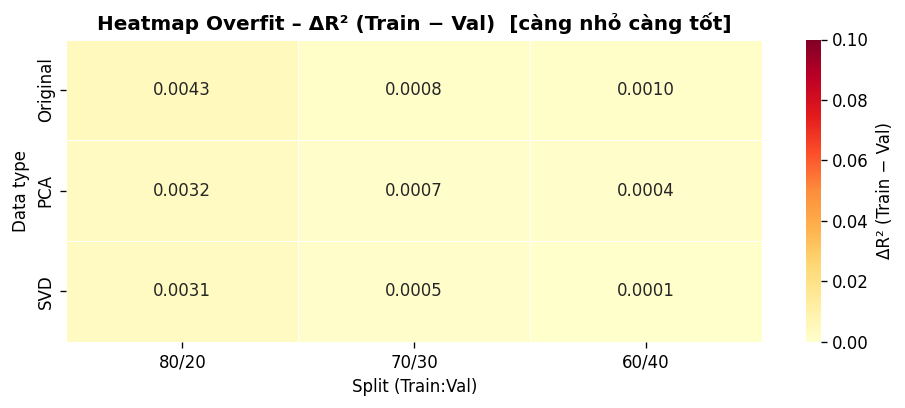


ΔR² < 0.01 → không overfit đáng kể
ΔR² 0.01–0.05 → overfit nhẹ
ΔR² > 0.05  → overfit cần xử lý


In [8]:
# Heatmap ΔR² – mức độ overfit theo Data type và Split
pivot = results_df.pivot_table(index='Data', columns='Split', values='Delta_R2')
split_order = ['80/20', '70/30', '60/40']
pivot = pivot[[s for s in split_order if s in pivot.columns]]

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'ΔR² (Train − Val)'}, ax=ax, vmin=0, vmax=0.1)
ax.set_title('Heatmap Overfit – ΔR² (Train − Val)  [càng nhỏ càng tốt]', fontweight='bold')
ax.set_xlabel('Split (Train:Val)')
ax.set_ylabel('Data type')
plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/overfit_heatmap.png', bbox_inches='tight')
plt.show()
print("\nΔR² < 0.01 → không overfit đáng kể")
print("ΔR² 0.01–0.05 → overfit nhẹ")
print("ΔR² > 0.05  → overfit cần xử lý")


# 6. Biểu đồ tổng hợp Train vs Val R² theo nhóm

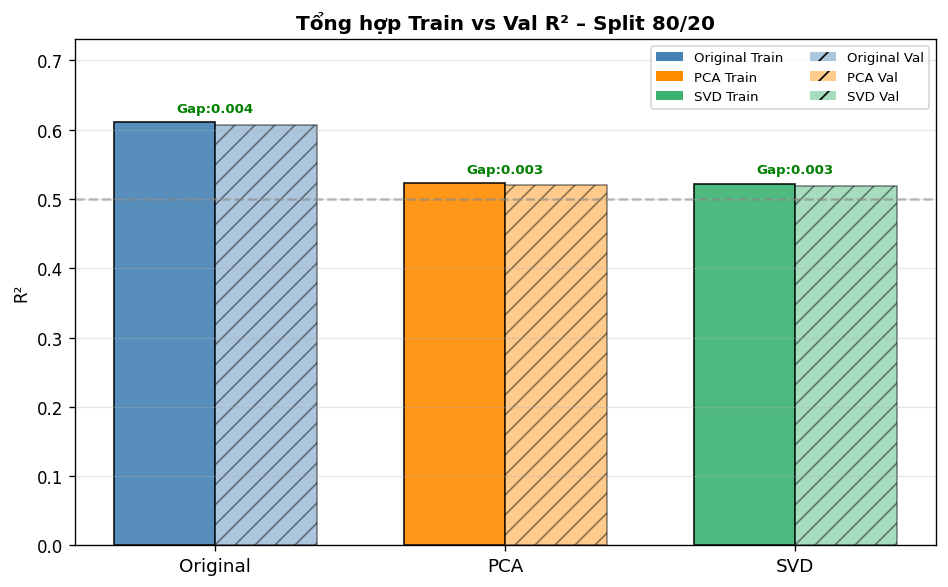

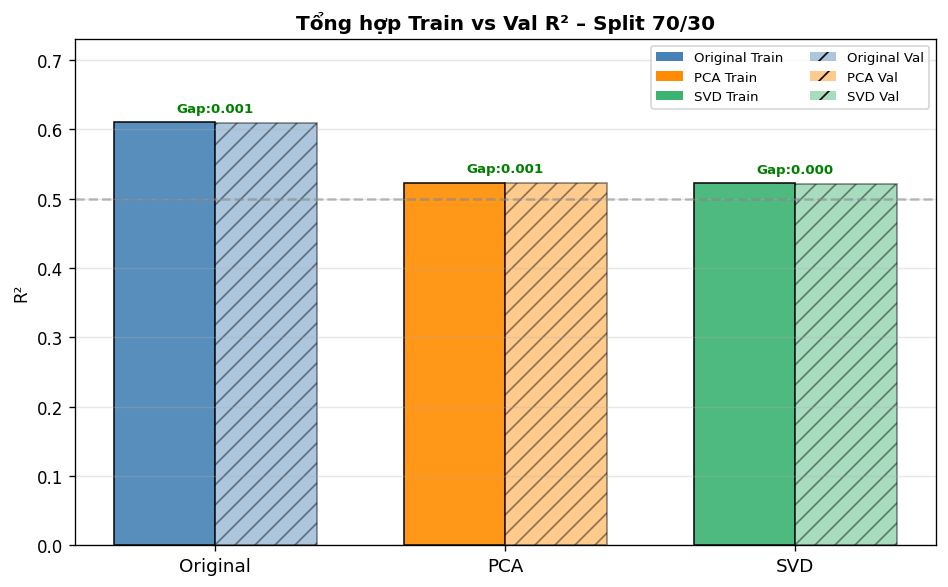

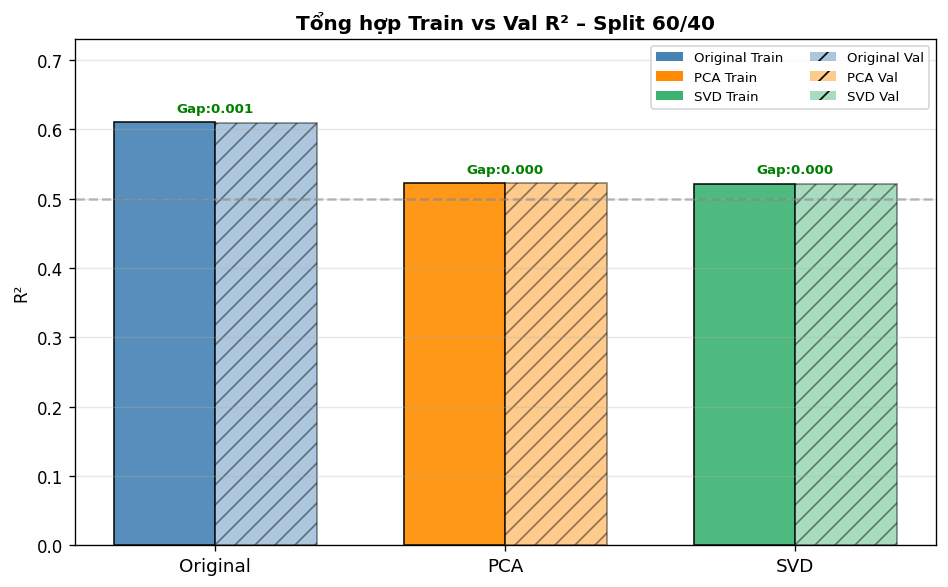

In [9]:
# Grouped bar: Train vs Val R² cho mỗi split
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
colors_dt = {'Original': 'steelblue', 'PCA': 'darkorange', 'SVD': 'mediumseagreen'}
split_order = ['80/20', '70/30', '60/40']

for split_label in split_order:
    sub = results_df[results_df['Split'] == split_label]
    if sub.empty:
        continue
    x = np.arange(len(sub))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, (_, row) in enumerate(sub.iterrows()):
        c = colors_dt.get(row['Data'], 'gray')
        ax.bar(i - width/2, row['Train_R2'], width, color=c, alpha=0.9,
               edgecolor='black', label=f"{row['Data']} Train" if split_label == '80/20' else '')
        ax.bar(i + width/2, row['Val_R2'],   width, color=c, alpha=0.45,
               edgecolor='black', hatch='//',
               label=f"{row['Data']} Test" if split_label == '80/20' else '')
        gap = row['Delta_R2']
        y_pos = max(row['Train_R2'], row['Val_R2']) + 0.015
        ax.text(i, y_pos, f"Gap:{gap:.3f}",
                ha='center', fontsize=8,
                color='red' if gap > 0.05 else 'green', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(sub['Data'], fontsize=11)
    ax.set_ylabel('R²')
    ax.set_ylim(0, max(sub['Train_R2'].max(), sub['Val_R2'].max()) + 0.12)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='R²=0.5 baseline')
    ax.set_title(f'Tổng hợp Train vs Val R² – Split {split_label}', fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors_dt.get(m,'gray'), label=f'{m} Train') for m in avail_dt] + \
                      [Patch(facecolor=colors_dt.get(m,'gray'), alpha=0.45, hatch='//',
                             label=f'{m} Val') for m in avail_dt]
    ax.legend(handles=legend_elements, fontsize=8, ncol=2)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_METRICS}/grouped_bar_{split_label.replace("/", "")}.png', bbox_inches='tight')
    plt.show()


# 7. So sánh Original vs PCA vs SVD

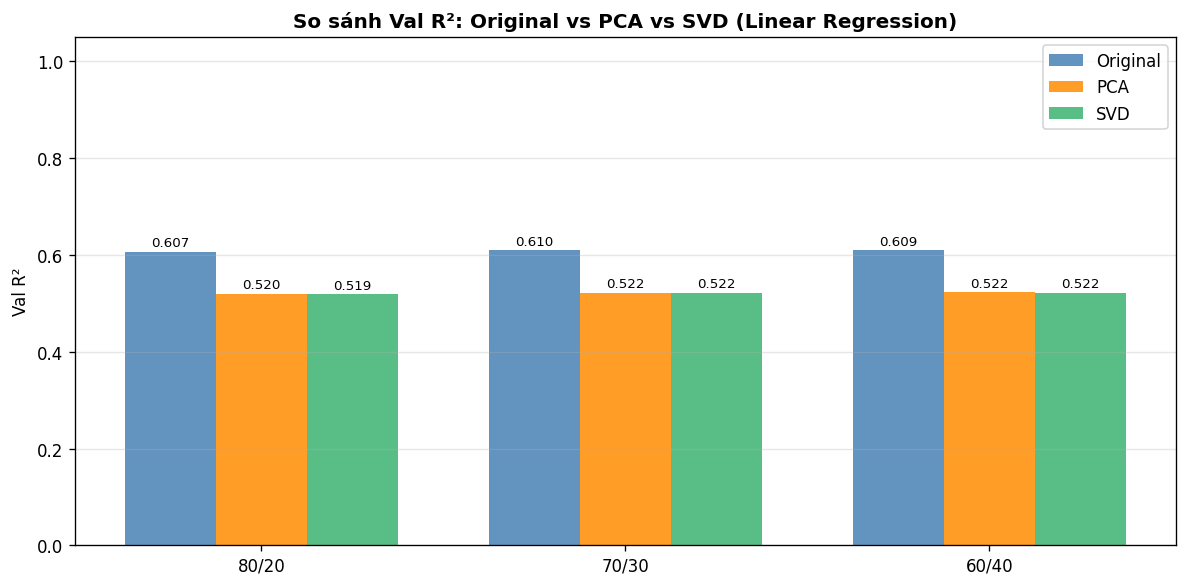

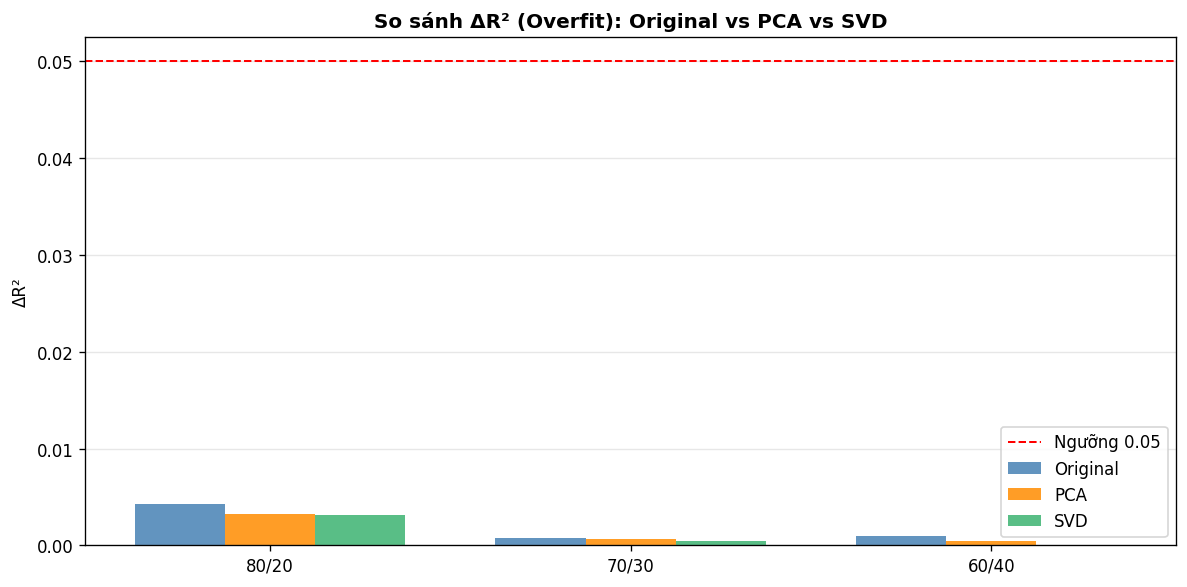


=== Mức giảm Val R² so với Original (split 80/20) ===
  PCA: Val R²=0.5197  ΔR²=+0.0869
  SVD: Val R²=0.5190  ΔR²=+0.0876


In [10]:
avail = results_df['Data'].unique()
dim_methods = [dt for dt in ['PCA', 'SVD'] if dt in avail]

if len(dim_methods) < 2:
    print('Chưa đủ dữ liệu để so sánh PCA và SVD (cần cả hai).')
else:
    split_order = ['80/20', '70/30', '60/40']
    colors_dt = {'Original': 'steelblue', 'PCA': 'darkorange', 'SVD': 'mediumseagreen'}
    dt_order = ['Original'] + dim_methods

    # Val R² so sánh
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(split_order))
    bar_width = 0.25
    for i, dt in enumerate(dt_order):
        vals = [results_df[(results_df['Data'] == dt) &
                           (results_df['Split'] == s)]['Val_R2'].values[0]
                if len(results_df[(results_df['Data'] == dt) &
                                  (results_df['Split'] == s)]) > 0 else np.nan
                for s in split_order]
        bars = ax.bar(x + i * bar_width, vals, bar_width,
                      label=dt, color=colors_dt.get(dt, 'gray'), alpha=0.85)
        for bar in bars:
            if not np.isnan(bar.get_height()):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(split_order)
    ax.set_ylabel('Val R²')
    ax.set_title('So sánh Val R²: Original vs PCA vs SVD (Linear Regression)', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_METRICS}/compare_original_pca_svd_r2.png', bbox_inches='tight')
    plt.show()

    # ΔR² so sánh
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, dt in enumerate(dt_order):
        vals = [results_df[(results_df['Data'] == dt) &
                           (results_df['Split'] == s)]['Delta_R2'].values[0]
                if len(results_df[(results_df['Data'] == dt) &
                                  (results_df['Split'] == s)]) > 0 else np.nan
                for s in split_order]
        ax.bar(x + i * bar_width, vals, bar_width,
               label=dt, color=colors_dt.get(dt, 'gray'), alpha=0.85)
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1.2, label='Ngưỡng 0.05')
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(split_order)
    ax.set_ylabel('ΔR²')
    ax.set_title('So sánh ΔR² (Overfit): Original vs PCA vs SVD', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_METRICS}/compare_original_pca_svd_delta_r2.png', bbox_inches='tight')
    plt.show()

    print('\n=== Mức giảm Val R² so với Original (split 80/20) ===')
    orig_r2 = results_df[(results_df['Data']=='Original') & (results_df['Split']=='80/20')]['Val_R2'].values[0]
    for dt in dim_methods:
        row = results_df[(results_df['Data']==dt) & (results_df['Split']=='80/20')]
        if len(row) == 0: continue
        delta = orig_r2 - row['Val_R2'].values[0]
        print(f'  {dt}: Val R²={row["Val_R2"].values[0]:.4f}  ΔR²={delta:+.4f}')


# 8. Phân tích phần dư – 1.4(b)
## 8.1 Load dữ liệu gốc split 7:3 cho cả 3 data types

In [11]:
import scipy.stats as stats

# Dùng split 7:3 cho phần dư (theo yêu cầu)
# Lưu residuals cho cả 3 data types với split 70/30
residuals_73 = {}

X_train_73_raw, X_val_73_raw, y_train_73, y_val_73 = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

for dt in data_types:
    X_train_ready, X_val_ready = prepare_features(
        X_train_73_raw,
        X_val_73_raw,
        method=dt,
        target_variance=0.8,
        random_state=SEED
    )
    model, tr_m, val_m, y_pred, resid = evaluate_lr(X_train_ready, X_val_ready, y_train_73, y_val_73)
    residuals_73[dt] = {
        'residuals': resid,
        'y_pred': y_pred,
        'y_val': y_val_73,
        'X_val': X_val_73_raw.copy().reset_index(drop=True),
        'X_val_model': X_val_ready,
        'model': model
    }
    print(f"[{dt}] Train R²={tr_m['R2']:.4f}  Val R²={val_m['R2']:.4f}  RMSE={val_m['RMSE']:.4f}")

[Original] Train R²=0.6103  Val R²=0.6095  RMSE=4.8411
[PCA] Train R²=0.5229  Val R²=0.5222  RMSE=5.3549
[SVD] Train R²=0.5221  Val R²=0.5216  RMSE=5.3582


## 8.2 Phần dư vs Dự đoán, Phần dư vs Thực tế, Thực tế vs Dự đoán

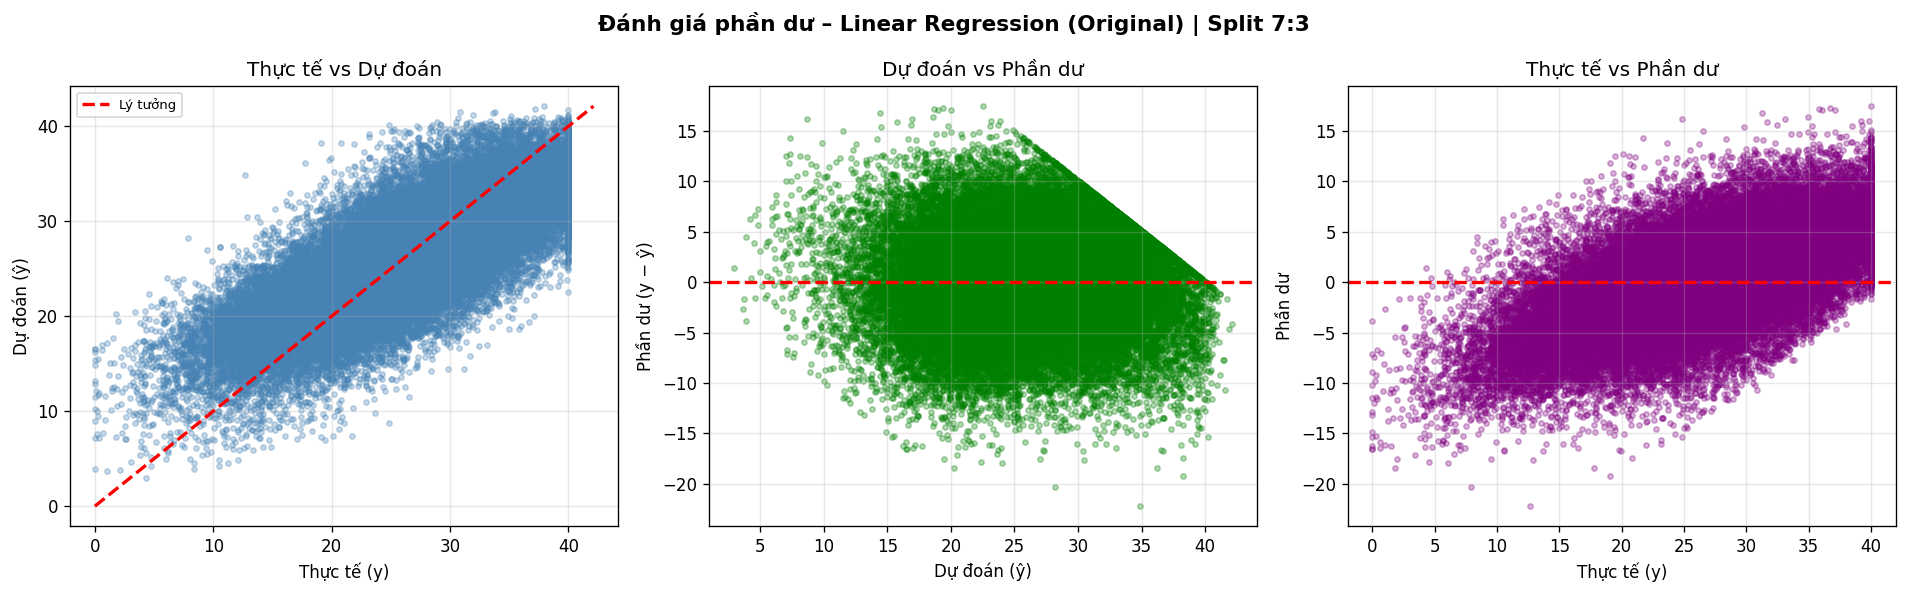

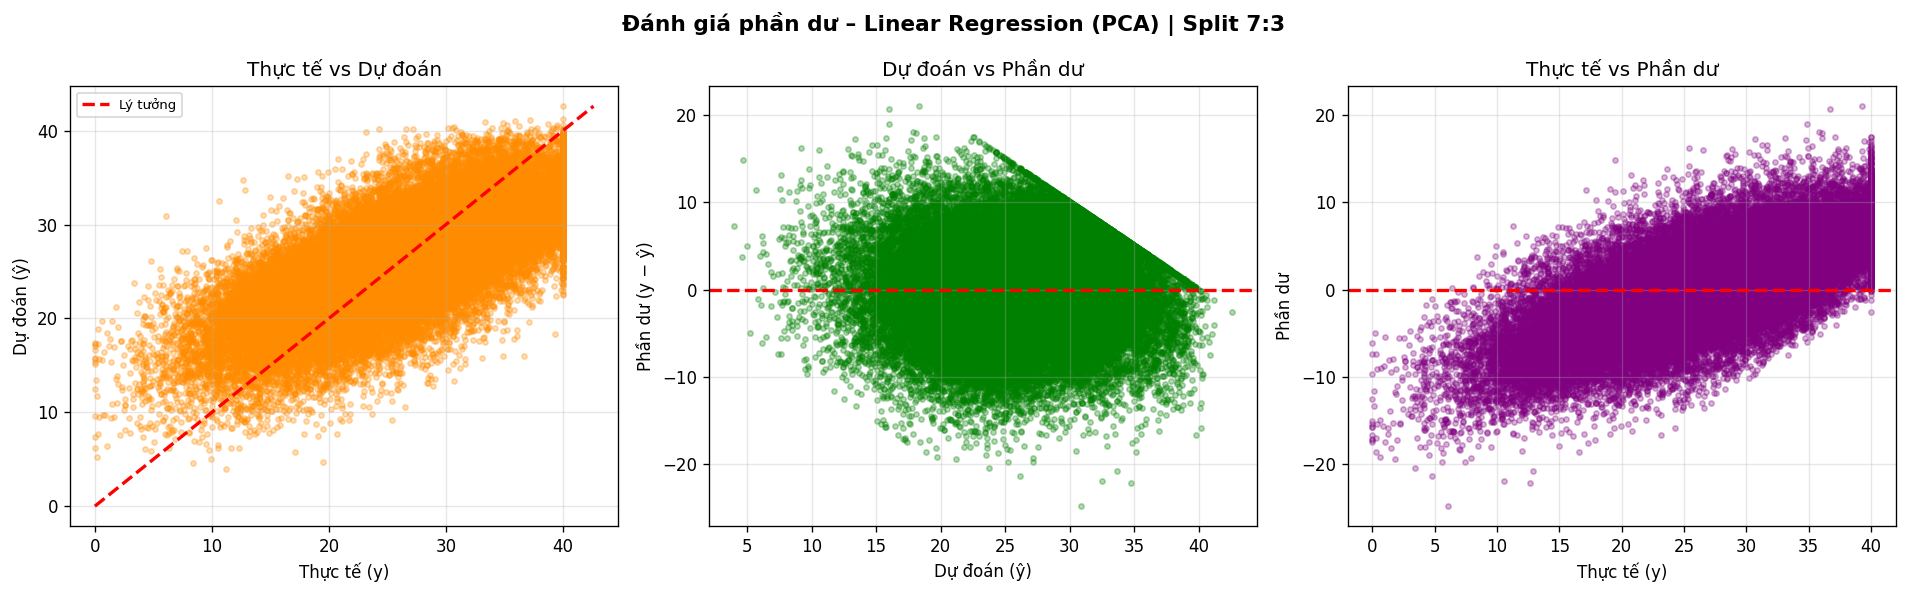

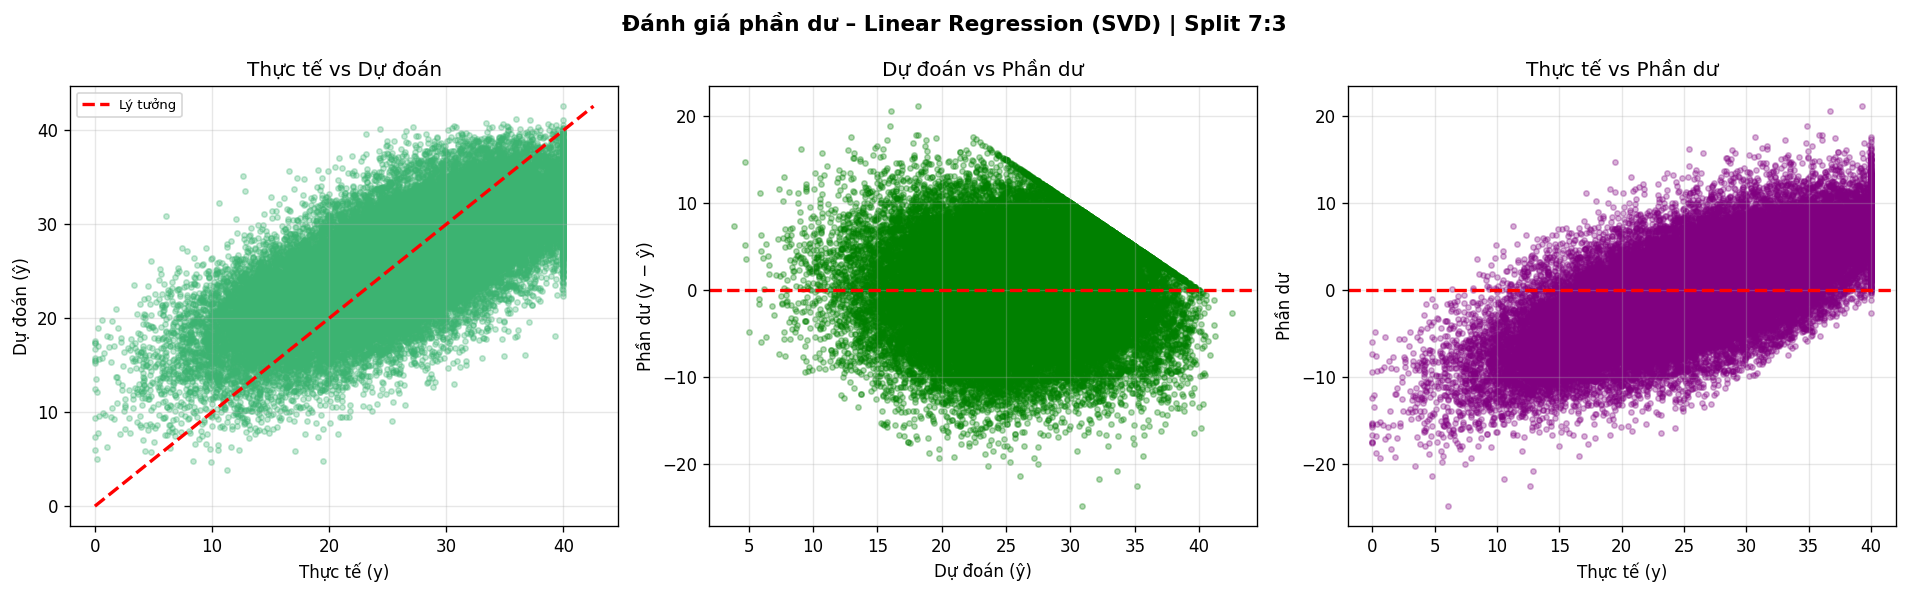

In [12]:
# Actual vs Pred / Pred vs Residual / Actual vs Residual – cho cả 3 data types
PALETTE_DT = {'Original': 'steelblue', 'PCA': 'darkorange', 'SVD': 'mediumseagreen'}

for method in [dt for dt in data_types if dt in residuals_73]:
    store = residuals_73[method]
    ya    = store['y_val']
    yp    = store['y_pred']
    resid = store['residuals']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    color = PALETTE_DT.get(method, 'steelblue')

    # Thực tế vs Dự đoán
    axes[0].scatter(ya, yp, alpha=0.3, s=10, color=color)
    mn, mx = min(ya.min(), yp.min()), max(ya.max(), yp.max())
    axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Lý tưởng')
    axes[0].set_title('Thực tế vs Dự đoán')
    axes[0].set_xlabel('Thực tế (y)')
    axes[0].set_ylabel('Dự đoán (ŷ)')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Dự đoán vs Phần dư
    axes[1].scatter(yp, resid, alpha=0.3, s=10, color='green')
    axes[1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1].set_title('Dự đoán vs Phần dư')
    axes[1].set_xlabel('Dự đoán (ŷ)')
    axes[1].set_ylabel('Phần dư (y − ŷ)')
    axes[1].grid(True, alpha=0.3)

    # Thực tế vs Phần dư
    axes[2].scatter(ya, resid, alpha=0.3, s=10, color='purple')
    axes[2].axhline(0, color='r', linestyle='--', lw=2)
    axes[2].set_title('Thực tế vs Phần dư')
    axes[2].set_xlabel('Thực tế (y)')
    axes[2].set_ylabel('Phần dư')
    axes[2].grid(True, alpha=0.3)

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Đánh giá phần dư – Linear Regression ({method}) | Split 7:3',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/residual_scatter_{method}.png', bbox_inches='tight')
    plt.show()


## 8.3 Phân phối phần dư 

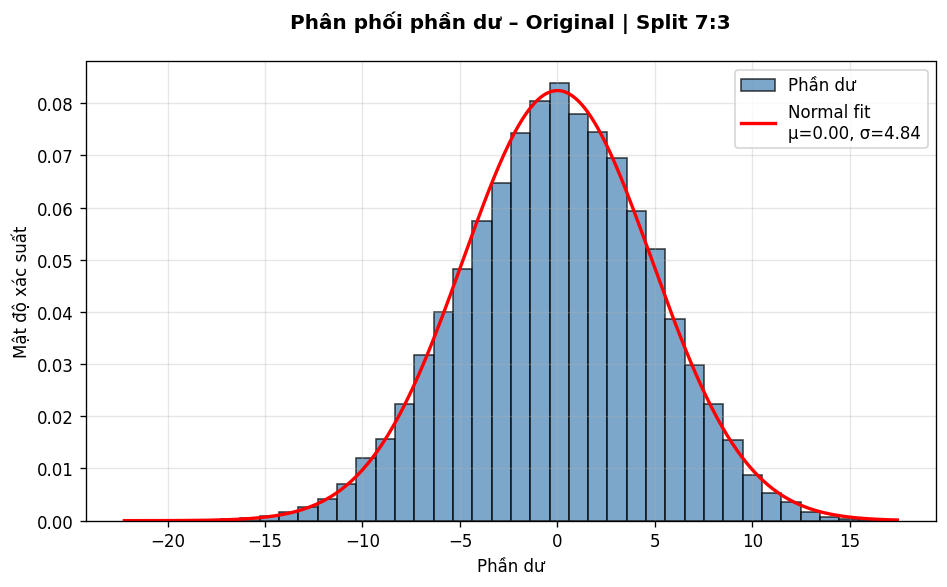

[Original] Mean=0.0020  Std=4.8411  Skew=-0.0946  Kurt=-0.0845


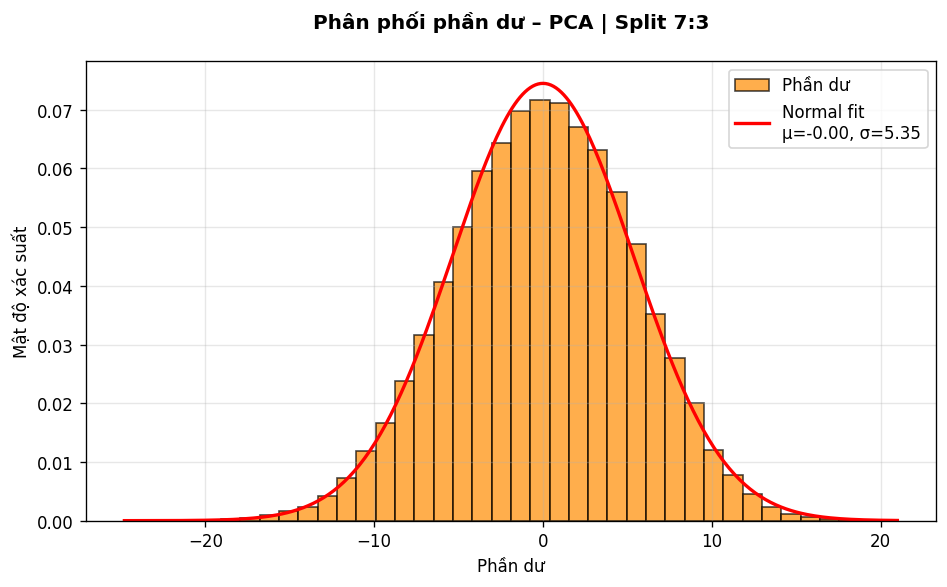

[PCA] Mean=-0.0010  Std=5.3549  Skew=-0.0819  Kurt=-0.1247


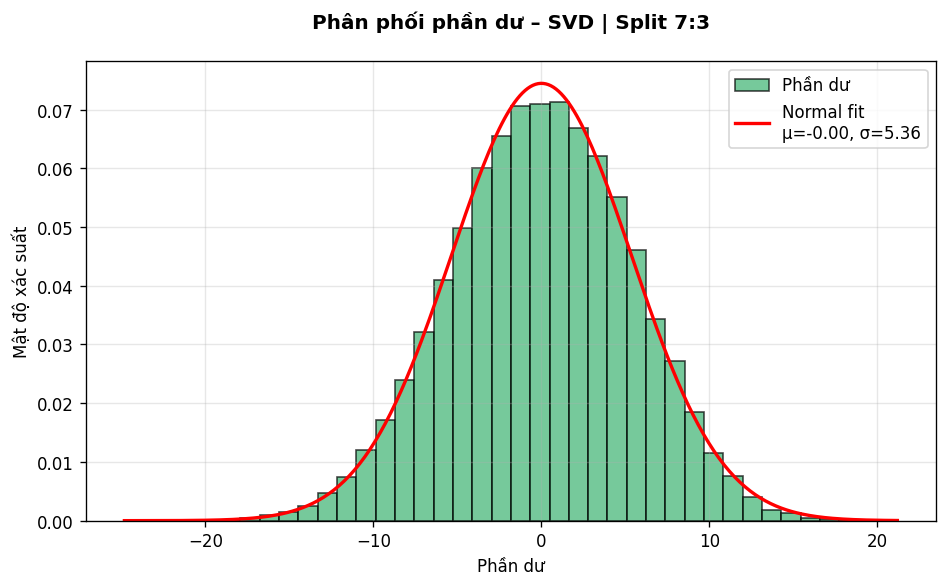

[SVD] Mean=-0.0021  Std=5.3582  Skew=-0.0818  Kurt=-0.1239


In [13]:
# Histogram phân phối phần dư + đường chuẩn fit
for method in [dt for dt in data_types if dt in residuals_73]:
    resid = residuals_73[method]['residuals']
    color = PALETTE_DT.get(method, 'steelblue')

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(resid, bins=40, color=color, edgecolor='black', alpha=0.7,
            density=True, label='Phần dư')

    # Normal fit
    mu, sigma = resid.mean(), resid.std()
    x_plot = np.linspace(resid.min(), resid.max(), 300)
    ax.plot(x_plot, stats.norm.pdf(x_plot, mu, sigma),
            'r-', lw=2, label=f'Normal fit\nμ={mu:.2f}, σ={sigma:.2f}')

    

    ax.set_title(f'Phân phối phần dư – {method} | Split 7:3\n',
                 fontweight='bold')
    ax.set_xlabel('Phần dư')
    ax.set_ylabel('Mật độ xác suất')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/residual_dist_{method}.png', bbox_inches='tight')
    plt.show()

    print(f"[{method}] Mean={mu:.4f}  Std={sigma:.4f}  "
          f"Skew={float(pd.Series(resid).skew()):.4f}  "
          f"Kurt={float(pd.Series(resid).kurtosis()):.4f}")

## 8.4 Q-Q Plot phần dư

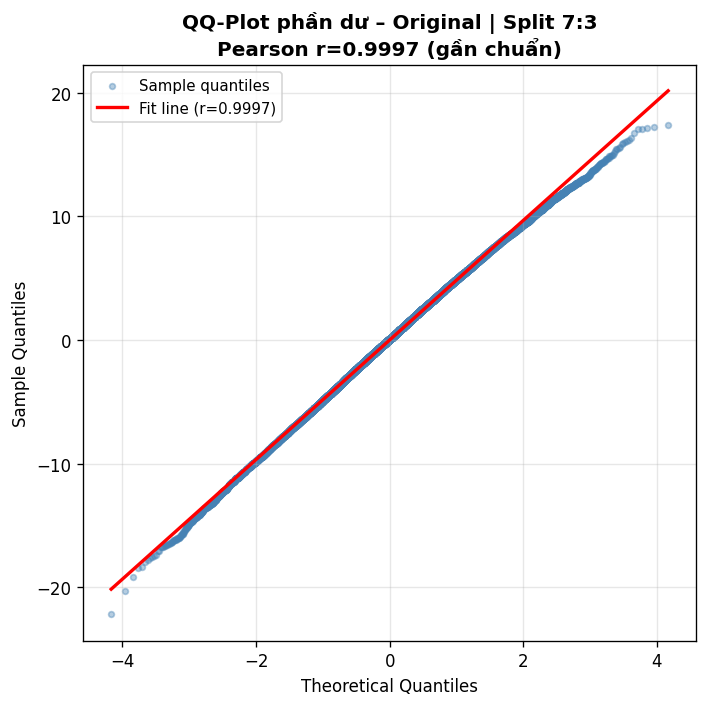

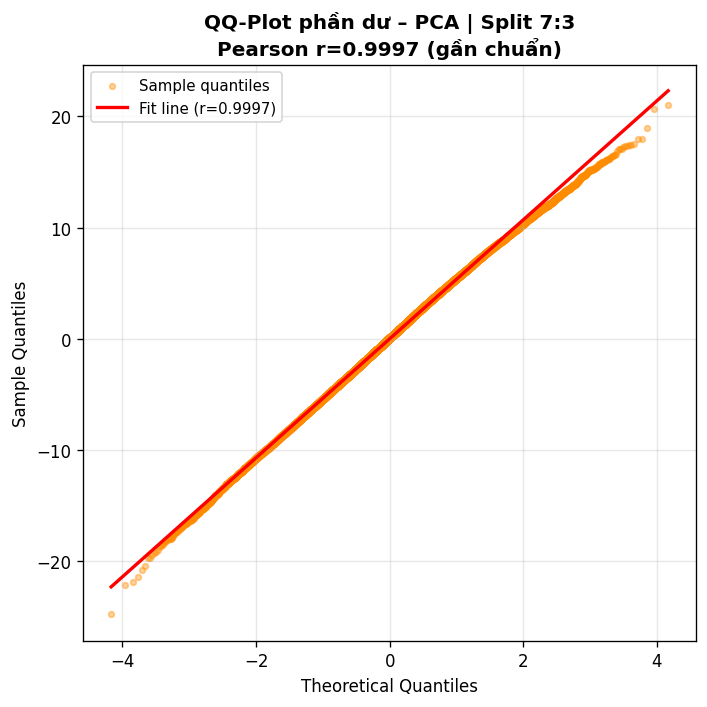

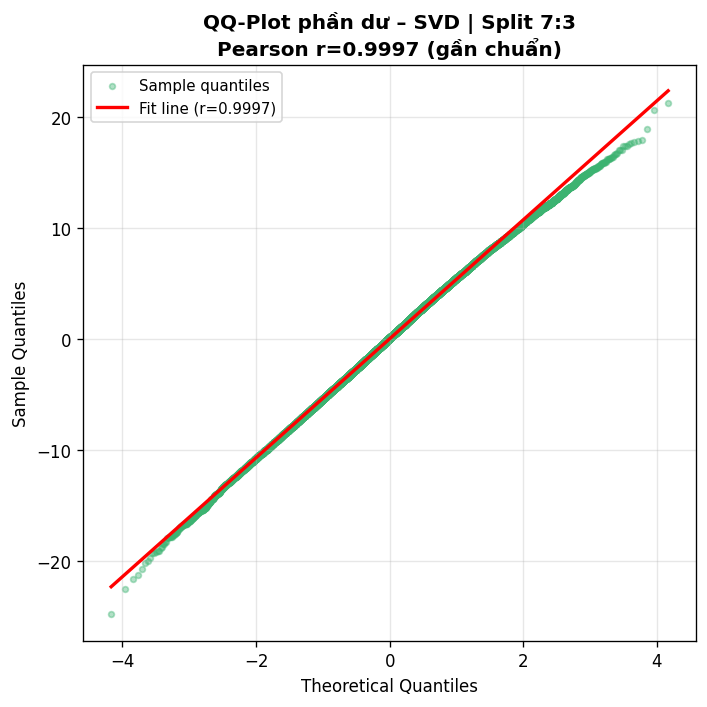

In [14]:
for method in [dt for dt in data_types if dt in residuals_73]:
    resid = residuals_73[method]['residuals']
    color = PALETTE_DT.get(method, 'steelblue')

    fig, ax = plt.subplots(figsize=(6, 6))
    (osm, osr), (slope, intercept, r_val) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, alpha=0.4, s=12, color=color, label='Sample quantiles')
    ax.plot(np.array(osm), slope * np.array(osm) + intercept,
            'r-', lw=2, label=f'Fit line (r={r_val:.4f})')
    verdict = 'gần chuẩn' if r_val > 0.99 else 'lệch khỏi chuẩn'
    ax.set_title(f'QQ-Plot phần dư – {method} | Split 7:3\n'
                 f'Pearson r={r_val:.4f} ({verdict})',
                 fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/qqplot_{method}.png', bbox_inches='tight')
    plt.show()


## 8.5 Tương quan phần dư với features (dữ liệu gốc, split 7:3)

In [15]:
# Dùng dữ liệu Original split 7:3
# Load X gốc (trước khi xử lý) để tách numeric vs categorical
# Ở đây dùng X_val từ residuals_73['Original'] – các cột trong X_val là sau xử lý

store_orig = residuals_73.get('Original')
if store_orig is None:
    print('[SKIP] Không có dữ liệu Original 7:3')
else:
    X_val_orig = store_orig['X_val'].copy().reset_index(drop=True)
    resid_73   = store_orig['residuals']

    # Tách biến số (numeric / ordinal): cột không có "_" hoặc không phải one-hot
    # Heuristic: cột mà nunique > 10 hoặc có giá trị liên tục → coi là numeric
    numeric_cols = [c for c in X_val_orig.columns
                    if X_val_orig[c].nunique() > 10]
    other_cols   = [c for c in X_val_orig.columns if c not in numeric_cols]

    print(f"Biến số (numeric/ordinal): {len(numeric_cols)} cột")
    print(f"Biến còn lại (cate/one-hot/chu kì): {len(other_cols)} cột")


Biến số (numeric/ordinal): 24 cột
Biến còn lại (cate/one-hot/chu kì): 62 cột


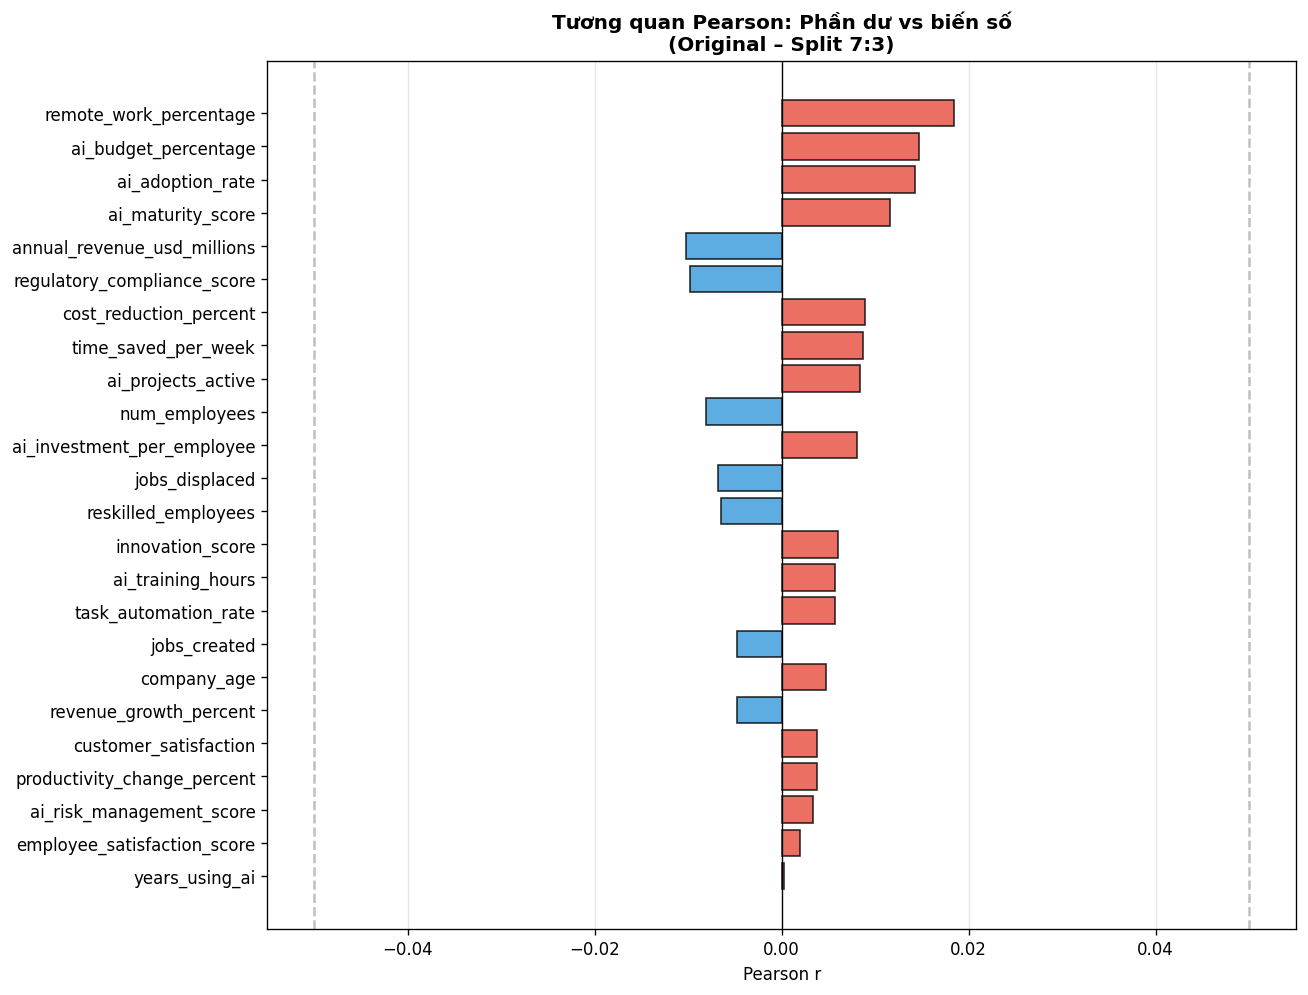

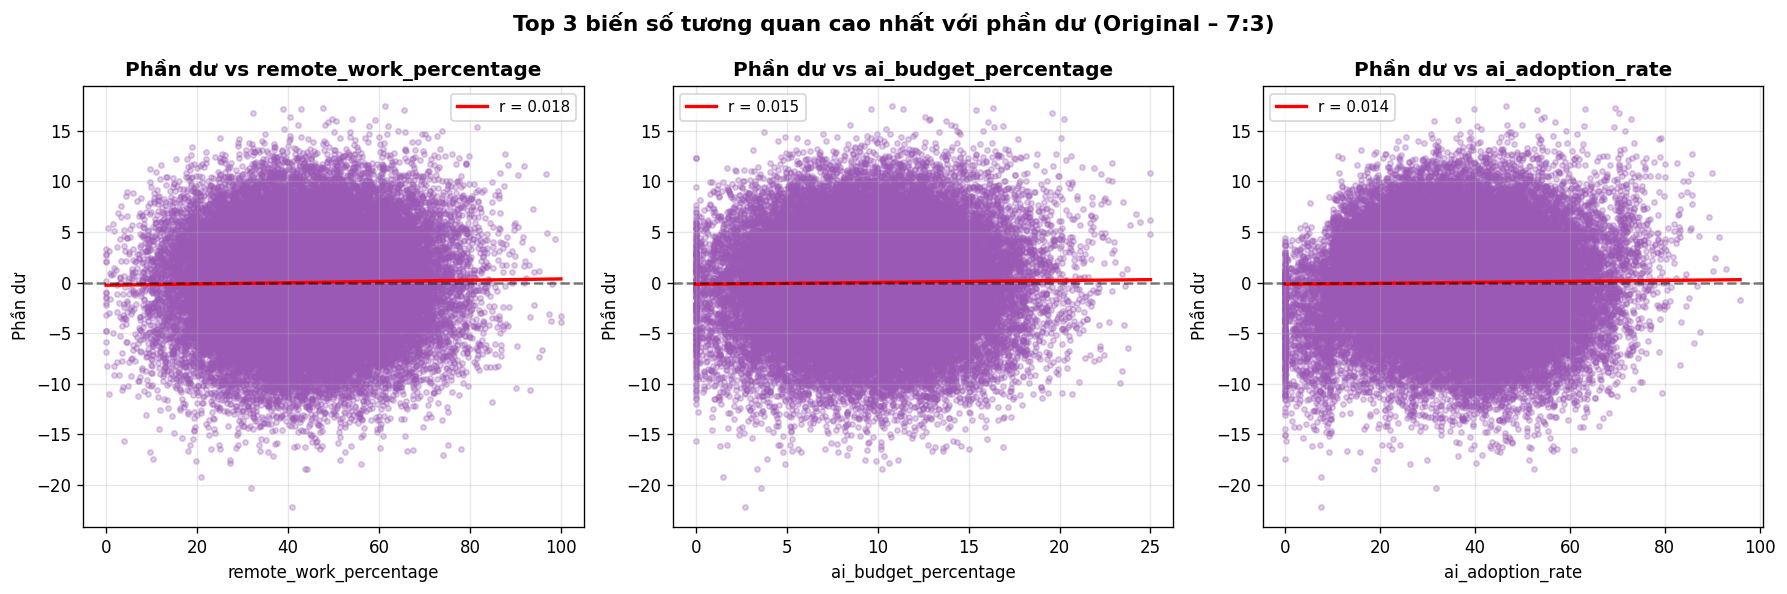

In [16]:
# Pearson correlation: phần dư vs biến số
if store_orig is not None and len(numeric_cols) > 0:
    corr_vals = {col: stats.pearsonr(X_val_orig[col], resid_73)[0]
                 for col in numeric_cols}
    corr_series = pd.Series(corr_vals).sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(11, max(5, len(numeric_cols)*0.35)))
    colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in corr_series.values]
    ax.barh(corr_series.index[::-1], corr_series.values[::-1],
            color=colors_bar[::-1], edgecolor='black', alpha=0.8)
    ax.axvline(0,     color='black', linewidth=0.8)
    ax.axvline( 0.05, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(-0.05, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('Tương quan Pearson: Phần dư vs biến số\n(Original – Split 7:3)',
                 fontweight='bold')
    ax.set_xlabel('Pearson r')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/corr_numeric_residual.png', bbox_inches='tight')
    plt.show()

    # Scatter top 3 biến tương quan cao nhất
    top3 = corr_series.head(3).index.tolist()
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, col in enumerate(top3):
        x_vals = X_val_orig[col].values
        axes[i].scatter(x_vals, resid_73, alpha=0.3, s=10, color='#9b59b6')
        m_fit, b_fit = np.polyfit(x_vals, resid_73, 1)
        xs = np.linspace(x_vals.min(), x_vals.max(), 200)
        axes[i].plot(xs, m_fit * xs + b_fit, 'r-', lw=2,
                     label=f'r = {corr_series[col]:.3f}')
        axes[i].axhline(0, color='black', linestyle='--', alpha=0.5)
        axes[i].set_title(f'Phần dư vs {col}', fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Phần dư')
        axes[i].legend(fontsize=9)
        axes[i].grid(True, alpha=0.3)
    plt.suptitle('Top 3 biến số tương quan cao nhất với phần dư (Original – 7:3)',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/top3_scatter_residual.png', bbox_inches='tight')
    plt.show()


## 8.6 Boxplot phần dư theo biến categorical / chu kỳ

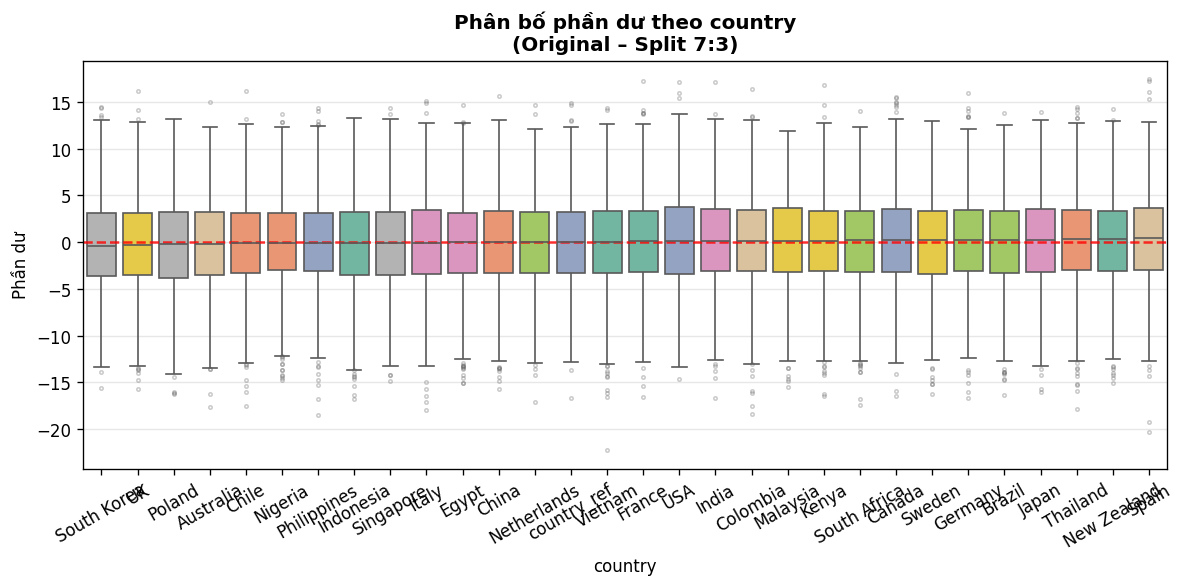

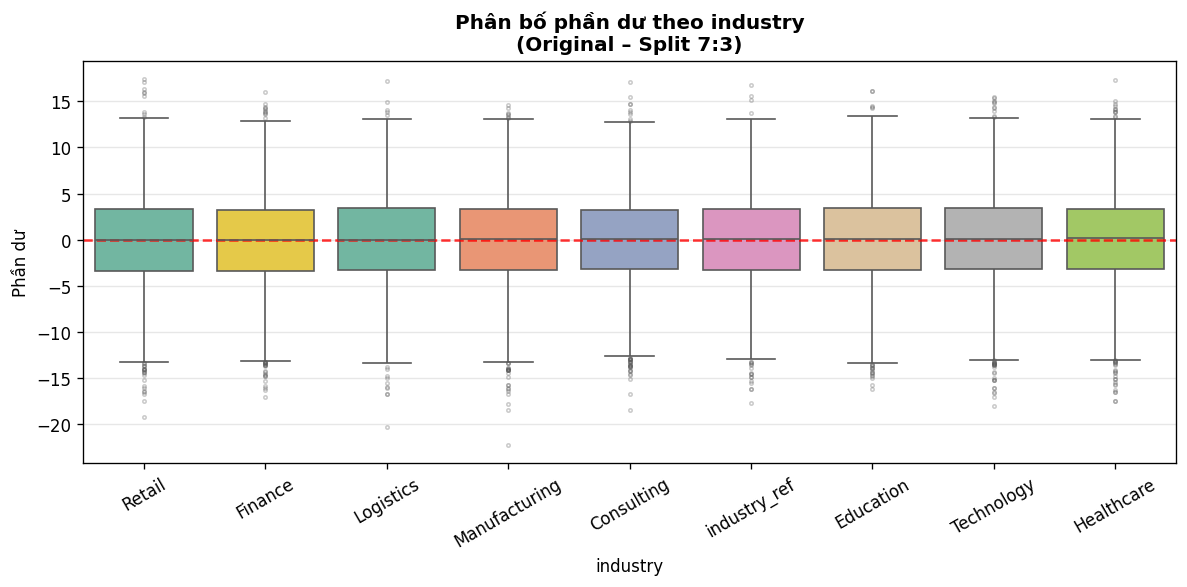

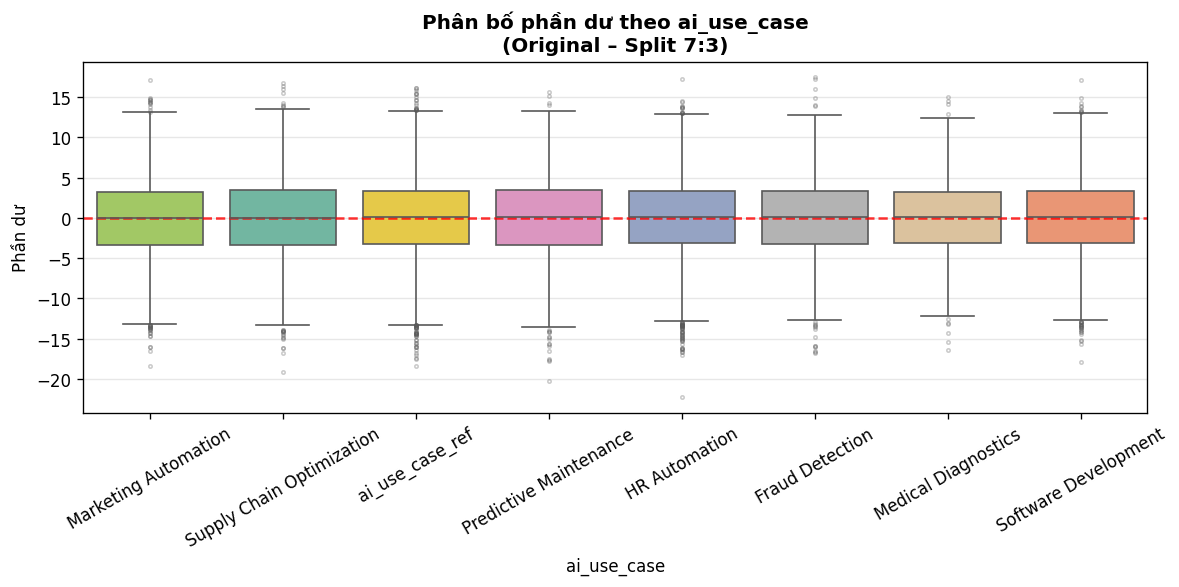

In [17]:
# Boxplot phần dư theo biến categorical (one-hot decoded)
if store_orig is not None and len(other_cols) > 0:

    def decode_onehot(X_df, prefix):
        """Decode one-hot cols có prefix thành label gốc."""
        cols = [c for c in X_df.columns if c.startswith(prefix + '_')]
        if not cols:
            return None
        decoded = X_df[cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)
        row_sum = X_df[cols].sum(axis=1)
        decoded[row_sum == 0] = f'{prefix}_ref'
        return decoded

    # Tìm các prefix one-hot phổ biến
    prefixes_found = {}
    for col in other_cols:
        if '_' in col:
            prefix = '_'.join(col.split('_')[:-1])
            prefixes_found[prefix] = prefixes_found.get(prefix, 0) + 1

    # Chọn tối đa 3 prefix có nhiều cột nhất
    top_prefixes = sorted(prefixes_found, key=lambda p: prefixes_found[p], reverse=True)[:3]

    # Nếu không có prefix, dùng binary cols (nunique == 2)
    binary_cols = [c for c in other_cols if X_val_orig[c].nunique() == 2]

    chosen_cats = {}
    for pref in top_prefixes:
        decoded = decode_onehot(X_val_orig, pref)
        if decoded is not None:
            chosen_cats[pref] = decoded

    # Fallback: binary cols nếu không có prefix
    if not chosen_cats and binary_cols:
        for col in binary_cols[:3]:
            chosen_cats[col] = X_val_orig[col].map({0: f'{col}=0', 1: f'{col}=1'})

    if not chosen_cats:
        print('[INFO] Không tìm thấy biến categorical phù hợp để vẽ boxplot.')
    else:
        for cat_name, cat_series in chosen_cats.items():
            df_plot = pd.DataFrame({'Category': cat_series.values, 'Residual': resid_73})
            order = df_plot.groupby('Category')['Residual'].median().sort_values().index

            fig, ax = plt.subplots(figsize=(10, 5))
            sns.boxplot(data=df_plot, x='Category', y='Residual', order=order,
                        ax=ax, palette='Set2', hue='Category', legend=False,
                        flierprops=dict(marker='.', alpha=0.3, markersize=4))
            ax.axhline(0, color='red', linestyle='--', lw=1.5, alpha=0.8)
            ax.set_title(f'Phân bố phần dư theo {cat_name}\n(Original – Split 7:3)',
                         fontweight='bold')
            ax.set_xlabel(cat_name)
            ax.set_ylabel('Phần dư')
            ax.tick_params(axis='x', rotation=30)
            ax.grid(True, axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{FIG_RESID}/boxplot_residual_{cat_name.replace("/","_")}.png',
                        bbox_inches='tight')
            plt.show()
